# NB-1 · CervixViT — Data Preprocessing & EDA
**Paper**: *DualPathCervixNet: A Novel Hybrid CNN-Transformer with Cross-Attention Fusion for Cervical Cell Classification*  
**Dataset**: SIPaKMeD — 4,049 Pap smear cell images, 5 classes  
**Journal Target**: Computers in Biology and Medicine (Q1, IF 7.7)  

### Outputs saved to `/kaggle/working/`
- `train.csv`, `val.csv`, `test.csv` — split file paths + labels  
- `class_weights.npy` — inverse-frequency weights for CWCFL loss  
- `eda_figures/` — all EDA plots for the paper

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install albumentations --quiet
!pip install timm --quiet

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, cv2, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Libraries loaded ✓')
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

Libraries loaded ✓
PyTorch 2.10.0+cu128 | CUDA: True


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
class CFG:
    SEED        = 42
    IMG_SIZE    = 224
    BATCH_SIZE  = 32
    NUM_CLASSES = 5

    # Kaggle dataset path — add 'cervical-cancer-largest-dataset-sipakmed' in dataset tab
    DATA_DIR = Path('/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed')
    OUT_DIR  = Path('/kaggle/working')
    FIG_DIR  = Path('/kaggle/working/eda_figures')

    CLASS_NAMES = [
        'Dyskeratotic',
        'Koilocytotic',
        'Metaplastic',
        'Parabasal',
        'Superficial-Intermediate'
    ]
    # Shortened labels for plots
    CLASS_SHORT = ['Dyskerat.', 'Koiloc.', 'Metaplas.', 'Parabasal', 'Superf.']

    TRAIN_RATIO = 0.70
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.15

CFG.FIG_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
print('Config set ✓')

Config set ✓


In [4]:
# ── 1. Load all image paths ───────────────────────────────────────────────────
def load_sipakmed_paths(data_dir, class_names):
    """
    SIPaKMeD structure:
      Im_{ClassName}/
        CROPPED/  ← individual segmented cells  (we use these)
        WHOLE/    ← full slide images
    """
    records = []
    for label, cls in enumerate(class_names):
        # Added the double-nested candidate based on the Kaggle dataset structure
        candidates = [
            data_dir / f'im_{cls}' / f'im_{cls}' / 'CROPPED', # <-- NEW: Fixes the double nesting
            data_dir / f'im_{cls}' / 'CROPPED',
            data_dir / f'Im_{cls}' / 'CROPPED',
            data_dir / f'Im_{cls}',
            data_dir / cls,
        ]
        search_dir = next((p for p in candidates if p.exists()), None)
        if search_dir is None:
            print(f'  ⚠ Could not find folder for class: {cls}')
            continue

        exts = ['*.bmp', '*.BMP', '*.jpg', '*.JPG', '*.jpeg', '*.png']
        imgs = [p for ext in exts for p in search_dir.glob(ext)]

        for img_path in imgs:
            records.append({
                'path':       str(img_path),
                'class_name': cls,
                'label':      label
            })
        print(f'  {cls:30s}: {len(imgs):4d} images  [{search_dir}]')

    df = pd.DataFrame(records)
    print(f'\nTotal: {len(df)} images across {df["label"].nunique()} classes')
    return df

df_all = load_sipakmed_paths(CFG.DATA_DIR, CFG.CLASS_NAMES)
df_all.head()

  Dyskeratotic                  :  813 images  [/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Dyskeratotic/im_Dyskeratotic/CROPPED]
  Koilocytotic                  :  825 images  [/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Koilocytotic/im_Koilocytotic/CROPPED]
  Metaplastic                   :  793 images  [/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Metaplastic/im_Metaplastic/CROPPED]
  Parabasal                     :  787 images  [/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Parabasal/im_Parabasal/CROPPED]
  Superficial-Intermediate      :  831 images  [/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/im_Superficial-Intermediate/im_Superficial-Intermediate/CROPPED]

Total: 4049 images across 5 classes


,path,class_name,label
0,/kaggle/input/datasets/prahladmehandiratta/cer...,Dyskeratotic,0
1,/kaggle/input/datasets/prahladmehandiratta/cer...,Dyskeratotic,0
2,/kaggle/input/datasets/prahladmehandiratta/cer...,Dyskeratotic,0
3,/kaggle/input/datasets/prahladmehandiratta/cer...,Dyskeratotic,0
4,/kaggle/input/datasets/prahladmehandiratta/cer...,Dyskeratotic,0


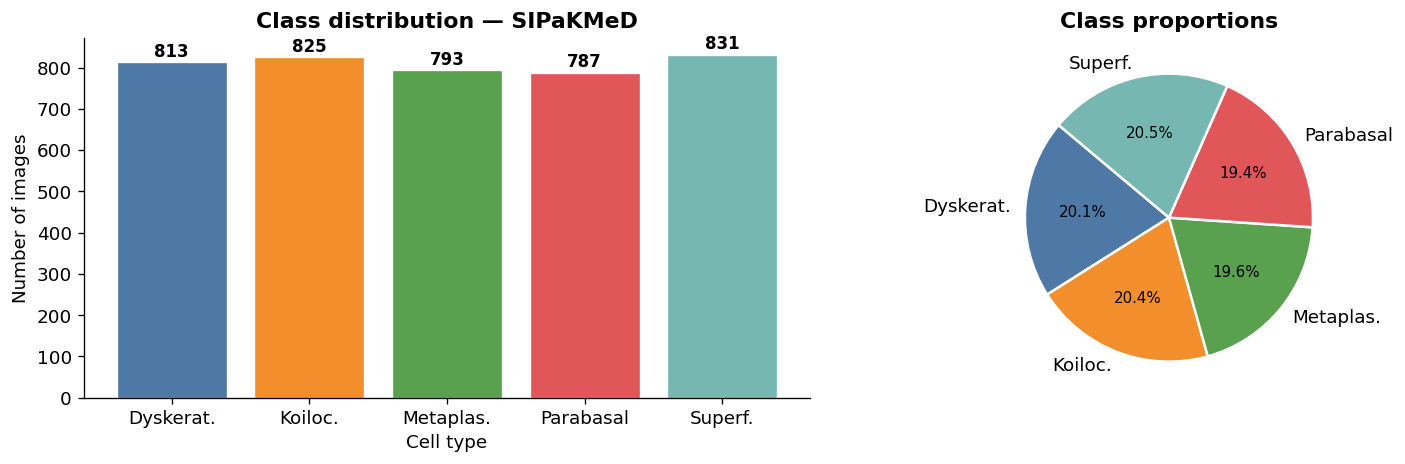

Imbalance ratio (max/min): 1.06  → justifies CWCFL loss


In [5]:
# ── 2. EDA — Class Distribution ───────────────────────────────────────────────
counts = df_all['class_name'].value_counts().reindex(CFG.CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
colors = ['#4E79A7','#F28E2B','#59A14F','#E15759','#76B7B2']
bars = axes[0].bar(CFG.CLASS_SHORT, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class distribution — SIPaKMeD', fontweight='bold')
axes[0].set_ylabel('Number of images')
axes[0].set_xlabel('Cell type')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=CFG.CLASS_SHORT, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Class proportions', fontweight='bold')

plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# Imbalance ratio
imb_ratio = counts.max() / counts.min()
print(f'Imbalance ratio (max/min): {imb_ratio:.2f}  → justifies CWCFL loss')

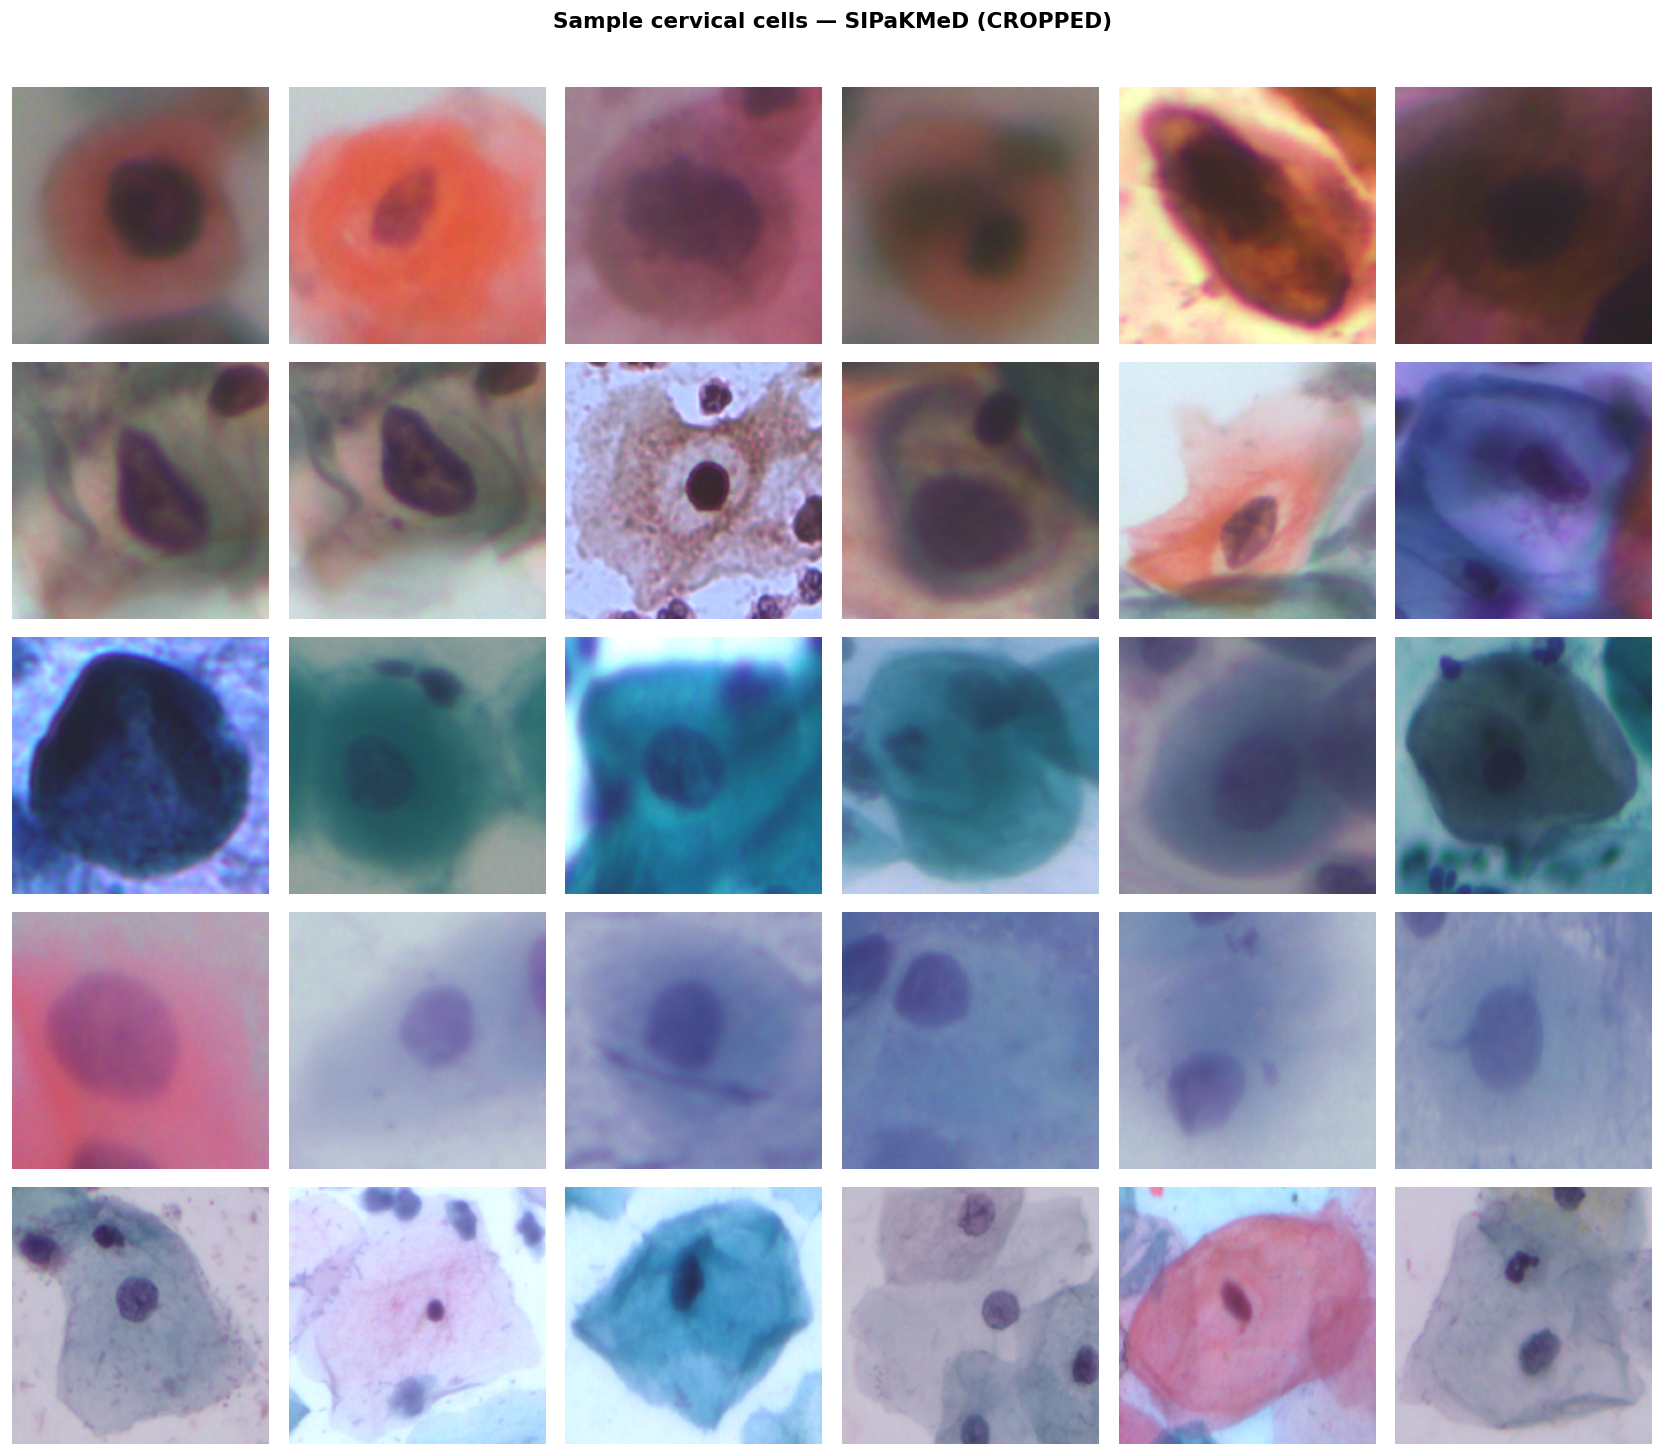

In [6]:
# ── 3. EDA — Sample Images per Class ─────────────────────────────────────────
fig, axes = plt.subplots(5, 6, figsize=(14, 12))
fig.suptitle('Sample cervical cells — SIPaKMeD (CROPPED)', fontsize=13, fontweight='bold', y=1.01)

for row, cls in enumerate(CFG.CLASS_NAMES):
    subset = df_all[df_all['class_name'] == cls].sample(min(6, len(df_all[df_all['class_name']==cls])),
                                                         random_state=42)
    for col, (_, rec) in enumerate(subset.iterrows()):
        img = cv2.imread(rec['path'])
        if img is None:
            axes[row, col].axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (CFG.IMG_SIZE, CFG.IMG_SIZE))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(CFG.CLASS_SHORT[row], rotation=0,
                                       labelpad=55, fontsize=10, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'sample_images.png', bbox_inches='tight', dpi=150)
plt.show()

Computing image statistics (sample of 200 images)...
Image sizes  — H: 187±87px  W: 215±96px
Channel means (0-255)  R:137.3  G:135.0  B:158.3

Using ImageNet normalization: mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


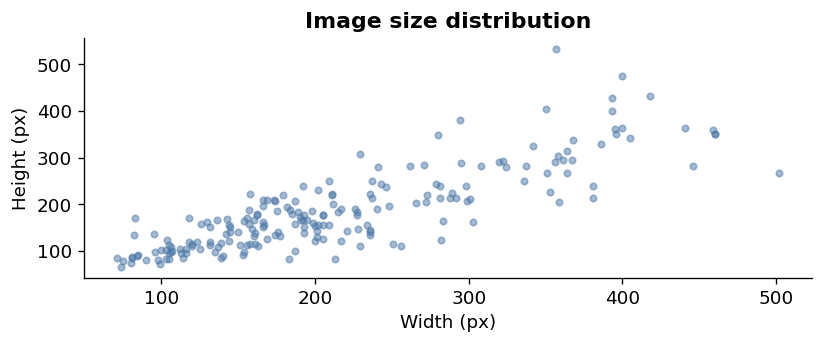

In [7]:
# ── 4. EDA — Image statistics (size, channel mean/std) ───────────────────────
print('Computing image statistics (sample of 200 images)...')
sample_df = df_all.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(40, len(x)), random_state=42)
)

heights, widths, means_r, means_g, means_b = [], [], [], [], []
for _, row in sample_df.iterrows():
    img = cv2.imread(row['path'])
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)
    means_r.append(img_rgb[:,:,0].mean())
    means_g.append(img_rgb[:,:,1].mean())
    means_b.append(img_rgb[:,:,2].mean())

print(f'Image sizes  — H: {np.mean(heights):.0f}±{np.std(heights):.0f}px  '
      f'W: {np.mean(widths):.0f}±{np.std(widths):.0f}px')
print(f'Channel means (0-255)  R:{np.mean(means_r):.1f}  G:{np.mean(means_g):.1f}  B:{np.mean(means_b):.1f}')

# Dataset-level mean and std for normalization (ImageNet values work well for pretrained models)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
print(f'\nUsing ImageNet normalization: mean={MEAN}  std={STD}')
np.save(CFG.OUT_DIR / 'norm_stats.npy', {'mean': MEAN, 'std': STD})

# Size distribution plot
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(widths, heights, alpha=0.5, s=15, color='#4E79A7')
ax.set_xlabel('Width (px)'); ax.set_ylabel('Height (px)')
ax.set_title('Image size distribution', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'image_sizes.png', bbox_inches='tight', dpi=150)
plt.show()

In [8]:
# ── 5. Train / Val / Test Split (stratified) ──────────────────────────────────
# Step 1: split off test set
df_trainval, df_test = train_test_split(
    df_all,
    test_size=CFG.TEST_RATIO,
    stratify=df_all['label'],
    random_state=CFG.SEED
)

# Step 2: split remaining into train and val
val_ratio_adjusted = CFG.VAL_RATIO / (CFG.TRAIN_RATIO + CFG.VAL_RATIO)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_ratio_adjusted,
    stratify=df_trainval['label'],
    random_state=CFG.SEED
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print('Split summary:')
print(f'  Train : {len(df_train):4d} images ({len(df_train)/len(df_all)*100:.1f}%)')
print(f'  Val   : {len(df_val):4d} images ({len(df_val)/len(df_all)*100:.1f}%)')
print(f'  Test  : {len(df_test):4d} images ({len(df_test)/len(df_all)*100:.1f}%)')

# Verify stratification
print('\nPer-class distribution (%):')
for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = split_df['label'].value_counts(normalize=True).sort_index() * 100
    print(f'  {split_name}: ' + '  '.join(f'{CFG.CLASS_SHORT[i]}: {v:.1f}%' for i, v in enumerate(dist)))

# Save splits
df_train.to_csv(CFG.OUT_DIR / 'train.csv', index=False)
df_val.to_csv(CFG.OUT_DIR   / 'val.csv',   index=False)
df_test.to_csv(CFG.OUT_DIR  / 'test.csv',  index=False)
print('\nSplits saved ✓')

Split summary:
  Train : 2833 images (70.0%)
  Val   :  608 images (15.0%)
  Test  :  608 images (15.0%)

Per-class distribution (%):
  Train: Dyskerat.: 20.1%  Koiloc.: 20.4%  Metaplas.: 19.6%  Parabasal: 19.4%  Superf.: 20.5%
  Val: Dyskerat.: 20.1%  Koiloc.: 20.4%  Metaplas.: 19.6%  Parabasal: 19.4%  Superf.: 20.6%
  Test: Dyskerat.: 20.1%  Koiloc.: 20.4%  Metaplas.: 19.6%  Parabasal: 19.4%  Superf.: 20.6%

Splits saved ✓


In [9]:
# ── 6. Compute Class Weights (for CWCFL loss) ─────────────────────────────────
train_counts = df_train['label'].value_counts().sort_index().values.astype(float)
# Inverse frequency, normalized
class_weights = 1.0 / train_counts
class_weights = class_weights / class_weights.sum() * CFG.NUM_CLASSES

print('Class weights for CWCFL loss:')
for i, (cls, w) in enumerate(zip(CFG.CLASS_SHORT, class_weights)):
    print(f'  [{i}] {cls:12s}: weight = {w:.4f}  (count = {int(train_counts[i])})')

np.save(CFG.OUT_DIR / 'class_weights.npy', class_weights)
print('\nclass_weights.npy saved ✓')

Class weights for CWCFL loss:
  [0] Dyskerat.   : weight = 0.9953  (count = 569)
  [1] Koiloc.     : weight = 0.9815  (count = 577)
  [2] Metaplas.   : weight = 1.0205  (count = 555)
  [3] Parabasal   : weight = 1.0279  (count = 551)
  [4] Superf.     : weight = 0.9748  (count = 581)

class_weights.npy saved ✓


In [10]:
# ── 7. Augmentation Strategy ──────────────────────────────────────────────────
#
# Medical image augmentation must preserve diagnostic morphology.
# We avoid: heavy elastic distortions, extreme colour shifts that mimic staining artefacts
# We use: geometric transforms, mild colour jitter, blur (simulates focus variation)
#
def get_train_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                           rotate_limit=20, border_mode=0, p=0.5),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5)),
            A.MedianBlur(blur_limit=3),
            A.MotionBlur(blur_limit=3),
        ], p=0.3),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10),
        ], p=0.4),
        A.CoarseDropout(max_holes=4, max_height=16, max_width=16,
                        min_holes=1, fill_value=0, p=0.2),  # simulate occlusion
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_val_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

print('Augmentation pipelines defined ✓')
print('Train:', [t.__class__.__name__ for t in get_train_transforms(224).transforms])

Augmentation pipelines defined ✓
Train: ['Resize', 'HorizontalFlip', 'VerticalFlip', 'RandomRotate90', 'ShiftScaleRotate', 'OneOf', 'OneOf', 'CoarseDropout', 'Normalize', 'ToTensorV2']


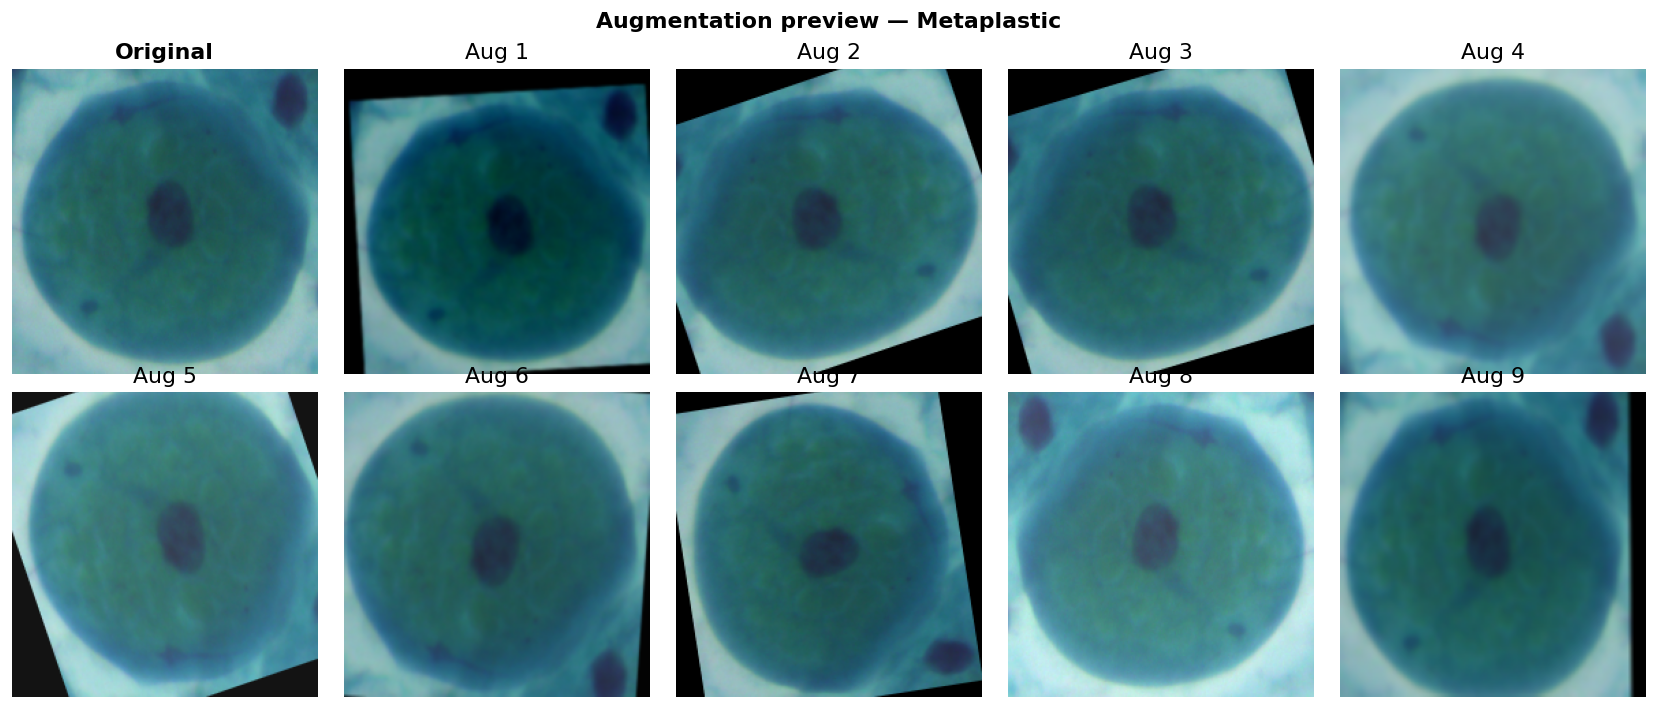

In [11]:
# ── 8. Visualise Augmentations ────────────────────────────────────────────────
sample_row = df_train.sample(1, random_state=0).iloc[0]
orig_img   = cv2.cvtColor(cv2.imread(sample_row['path']), cv2.COLOR_BGR2RGB)
orig_img   = cv2.resize(orig_img, (CFG.IMG_SIZE, CFG.IMG_SIZE))

aug_pipeline = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=20, border_mode=0, p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.8),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(f'Augmentation preview — {sample_row["class_name"]}', fontweight='bold')
axes[0, 0].imshow(orig_img)
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 10):
    aug = aug_pipeline(image=orig_img)['image']
    r, c = divmod(i, 5)
    axes[r, c].imshow(aug)
    axes[r, c].set_title(f'Aug {i}')
    axes[r, c].axis('off')

plt.tight_layout()
plt.savefig(CFG.FIG_DIR / 'augmentations.png', bbox_inches='tight', dpi=150)
plt.show()

In [12]:
# ── 9. Dataset Class ──────────────────────────────────────────────────────────
class CervixDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        image  = cv2.imread(row['path'])
        image  = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label  = int(row['label'])

        if self.transform:
            image = self.transform(image=image)['image']

        return image, label


# Quick smoke test
train_ds = CervixDataset(df_train, get_train_transforms(CFG.IMG_SIZE))
val_ds   = CervixDataset(df_val,   get_val_transforms(CFG.IMG_SIZE))
test_ds  = CervixDataset(df_test,  get_val_transforms(CFG.IMG_SIZE))

train_dl = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE*2, shuffle=False,
                      num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE*2, shuffle=False,
                      num_workers=2, pin_memory=True)

imgs, lbls = next(iter(train_dl))
print(f'Batch shape: {imgs.shape}  Labels: {lbls[:8].tolist()}')
print(f'Train batches: {len(train_dl)} | Val batches: {len(val_dl)} | Test batches: {len(test_dl)}')
print('\nDataset & DataLoader verified ✓')

Batch shape: torch.Size([32, 3, 224, 224])  Labels: [1, 3, 0, 1, 4, 2, 3, 1]
Train batches: 89 | Val batches: 10 | Test batches: 10

Dataset & DataLoader verified ✓


In [13]:
# ── 10. Save augmentation functions for NB-2 ─────────────────────────────────
import pickle

# Save dataset config dict for NB-2 to load
config_dict = {
    'img_size':     CFG.IMG_SIZE,
    'num_classes':  CFG.NUM_CLASSES,
    'class_names':  CFG.CLASS_NAMES,
    'class_short':  CFG.CLASS_SHORT,
    'mean':         [0.485, 0.456, 0.406],
    'std':          [0.229, 0.224, 0.225],
    'seed':         CFG.SEED,
    'batch_size':   CFG.BATCH_SIZE,
}
with open(CFG.OUT_DIR / 'config.pkl', 'wb') as f:
    pickle.dump(config_dict, f)

print('All outputs saved to /kaggle/working/')
print('  train.csv, val.csv, test.csv')
print('  class_weights.npy')
print('  config.pkl')
print('  norm_stats.npy')
print('  eda_figures/')
print('\n✅ NB-1 Complete — proceed to NB-2 (Model Training)')

All outputs saved to /kaggle/working/
  train.csv, val.csv, test.csv
  class_weights.npy
  config.pkl
  norm_stats.npy
  eda_figures/

✅ NB-1 Complete — proceed to NB-2 (Model Training)
